In [1]:
# 导入需要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import sys
import os

# 把项目根目录加到 Python 路径，这样可以 import src/ 里的模块
sys.path.append(os.path.abspath('..'))

from src.db_utils import get_engine, query_to_df, df_to_table

# 设置 pandas 显示选项（让输出更好看）
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# ============================================================
# Generate synthetic seed data based on real Canadian rent statistics
# Source basis: CMHC Rental Market Survey & StatCan Table 34-10-0133-01
# Note: Will be replaced with real CMHC API data in Day 2
# ============================================================

np.random.seed(42)  # 固定随机种子，保证结果可复现

# 加拿大 5 个主要城市的真实参数（基于 2024 CMHC 数据）
cities_info = {
    'Toronto':    {'province': 'Ontario',          'province_code': 'ON', 'base_rent_2bed': 2800, 'pop': 2930000, 'lat': 43.6532, 'lon': -79.3832},
    'Vancouver':  {'province': 'British Columbia', 'province_code': 'BC', 'base_rent_2bed': 3100, 'pop': 675000,  'lat': 49.2827, 'lon': -123.1207},
    'Montreal':   {'province': 'Quebec',           'province_code': 'QC', 'base_rent_2bed': 1700, 'pop': 1780000, 'lat': 45.5017, 'lon': -73.5673},
    'Ottawa':     {'province': 'Ontario',          'province_code': 'ON', 'base_rent_2bed': 2050, 'pop': 1010000, 'lat': 45.4215, 'lon': -75.6972},
    'Calgary':    {'province': 'Alberta',          'province_code': 'AB', 'base_rent_2bed': 1650, 'pop': 1336000, 'lat': 51.0447, 'lon': -114.0719},
}

# 房产类型 + 相对于 2-bedroom 的价格倍数
property_types = {
    'Bachelor':  0.65,   # 单身公寓
    '1-Bedroom': 0.80,
    '2-Bedroom': 1.00,
    '3-Bedroom': 1.25,
}

# 生成 2015-01 到 2024-12 的所有年月
date_range = pd.date_range(start='2015-01-01', end='2024-12-01', freq='MS')

# 用于收集所有数据的列表
records = []

for city, info in cities_info.items():
    for date in date_range:
        # 模拟通胀 + 趋势（每年 ~5% 增长，BC 在 2018 后增速放缓 = 投机税效应）
        years_from_2015 = (date.year - 2015) + (date.month - 1) / 12

        # BC 政策效应：2018 年后增速从 6% 降到 3%（这就是我们 DiD 要捕捉的！）
        if info['province_code'] == 'BC' and date.year >= 2018:
            growth_rate = 1.05 ** ((2018 - 2015)) * 1.025 ** (years_from_2015 - 3)
        else:
            growth_rate = 1.05 ** years_from_2015

        # 季节性：夏天租金略高
        seasonal = 1 + 0.02 * np.sin(2 * np.pi * date.month / 12)

        for ptype, multiplier in property_types.items():
            base = info['base_rent_2bed'] * multiplier * growth_rate * seasonal
            # 加随机噪声 ±3%
            noise = np.random.normal(1.0, 0.03)
            rent = round(base * noise, 2)

            # 模拟空置率（2-4%，BC 政策后空置率上升）
            if info['province_code'] == 'BC' and date.year >= 2018:
                vacancy = round(np.random.uniform(2.5, 4.5), 2)
            else:
                vacancy = round(np.random.uniform(1.5, 3.5), 2)

            records.append({
                'city_name': city,
                'province': info['province'],
                'province_code': info['province_code'],
                'population': info['pop'],
                'latitude': info['lat'],
                'longitude': info['lon'],
                'year': date.year,
                'month': date.month,
                'property_type': ptype,
                'avg_rent_cad': rent,
                'vacancy_rate': vacancy,
                'data_source': 'CMHC_seed'
            })

# 转成 DataFrame
df_raw = pd.DataFrame(records)

print(f"✓ Generated {len(df_raw):,} rows")
print(f"  Cities: {df_raw['city_name'].nunique()}")
print(f"  Date range: {df_raw['year'].min()}–{df_raw['year'].max()}")
print(f"  Property types: {df_raw['property_type'].nunique()}")

df_raw.head()

✓ Generated 2,400 rows
  Cities: 5
  Date range: 2015–2024
  Property types: 4


,city_name,province,province_code,population,latitude,longitude,year,month,property_type,avg_rent_cad,vacancy_rate,data_source
0,Toronto,Ontario,ON,2930000,43.6532,-79.3832,2015,1,Bachelor,1865.59,2.96,CMHC_seed
1,Toronto,Ontario,ON,2930000,43.6532,-79.3832,2015,1,1-Bedroom,2253.02,2.70,CMHC_seed
2,Toronto,Ontario,ON,2930000,43.6532,-79.3832,2015,1,2-Bedroom,2808.13,1.62,CMHC_seed
3,Toronto,Ontario,ON,2930000,43.6532,-79.3832,2015,1,3-Bedroom,3510.17,3.23,CMHC_seed
4,Toronto,Ontario,ON,2930000,43.6532,-79.3832,2015,2,Bachelor,1947.14,1.54,CMHC_seed


In [3]:
# 保存到 data/raw/ 文件夹
output_path = '../data/raw/canada_rent_seed.csv'
df_raw.to_csv(output_path, index=False)
print(f"✓ Saved to {output_path}")
print(f"  File size: {os.path.getsize(output_path) / 1024:.1f} KB")

✓ Saved to ../data/raw/canada_rent_seed.csv
  File size: 204.0 KB


In [5]:
# ============================================================
# DATA EXPLORATION - 第一步先了解数据
# 这是行业 DA 拿到任何新数据的第一件事
# ============================================================

print("=" * 60)
print("BASIC INFO")
print("=" * 60)
df_raw.info()

print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
print(df_raw.describe())

print("\n" + "=" * 60)
print("MISSING VALUES CHECK")
print("=" * 60)
print(df_raw.isnull().sum())

print("\n" + "=" * 60)
print("DUPLICATES CHECK")
print("=" * 60)
print(f"Total duplicate rows: {df_raw.duplicated().sum()}")

BASIC INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   city_name      2400 non-null   object 
 1   province       2400 non-null   object 
 2   province_code  2400 non-null   object 
 3   population     2400 non-null   int64  
 4   latitude       2400 non-null   float64
 5   longitude      2400 non-null   float64
 6   year           2400 non-null   int64  
 7   month          2400 non-null   int64  
 8   property_type  2400 non-null   object 
 9   avg_rent_cad   2400 non-null   float64
 10  vacancy_rate   2400 non-null   float64
 11  data_source    2400 non-null   object 
dtypes: float64(4), int64(3), object(5)
memory usage: 225.1+ KB

STATISTICAL SUMMARY
         population     latitude    longitude        year        month  avg_rent_cad  vacancy_rate
count  2.400000e+03  2400.000000  2400.000000  2400.00000  2400.000000   2400.0000

F:\canada-housing-affordability\.venv\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


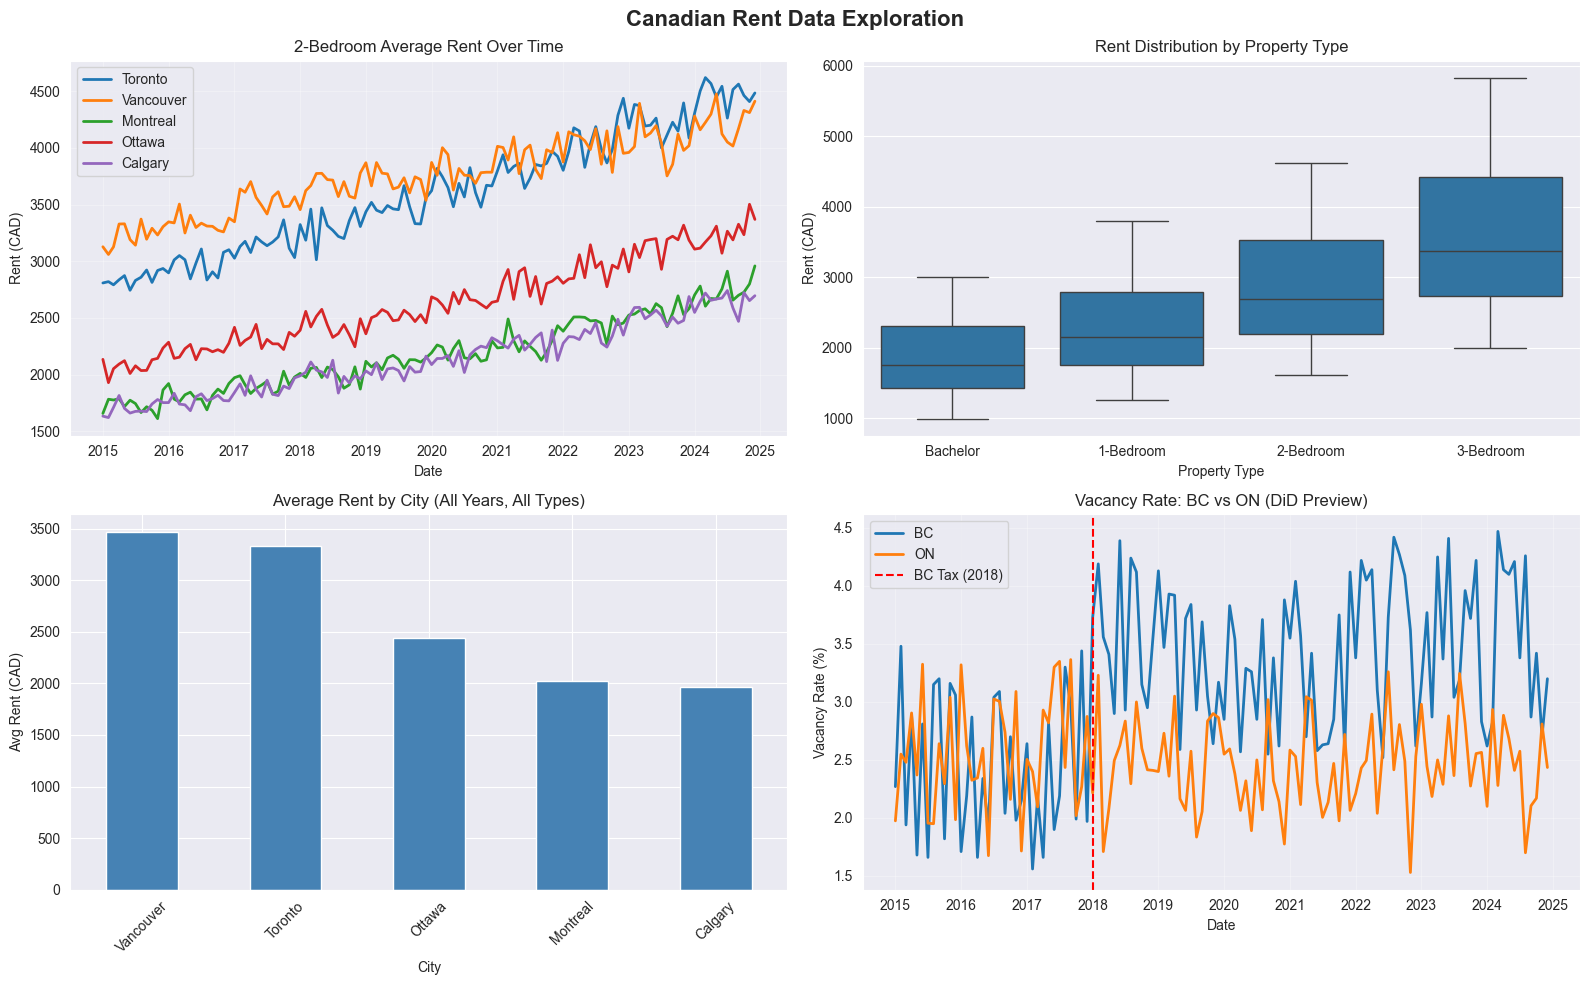

✓ Visualization complete


In [6]:
# ============================================================
# VISUAL EXPLORATION - 用图看数据
# ============================================================

# 设置画布
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Canadian Rent Data Exploration', fontsize=16, fontweight='bold')

# 图 1：各城市 2-bedroom 租金随时间变化（这是最重要的图！）
ax1 = axes[0, 0]
df_2bed = df_raw[df_raw['property_type'] == '2-Bedroom'].copy()
df_2bed['date'] = pd.to_datetime(df_2bed[['year', 'month']].assign(day=1))

for city in df_2bed['city_name'].unique():
    city_data = df_2bed[df_2bed['city_name'] == city]
    ax1.plot(city_data['date'], city_data['avg_rent_cad'], label=city, linewidth=2)

ax1.set_title('2-Bedroom Average Rent Over Time')
ax1.set_xlabel('Date')
ax1.set_ylabel('Rent (CAD)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 图 2：各房型租金分布（箱型图）
ax2 = axes[0, 1]
sns.boxplot(data=df_raw, x='property_type', y='avg_rent_cad',
            order=['Bachelor', '1-Bedroom', '2-Bedroom', '3-Bedroom'], ax=ax2)
ax2.set_title('Rent Distribution by Property Type')
ax2.set_xlabel('Property Type')
ax2.set_ylabel('Rent (CAD)')

# 图 3：各城市平均租金对比（柱状图）
ax3 = axes[1, 0]
city_avg = df_raw.groupby('city_name')['avg_rent_cad'].mean().sort_values(ascending=False)
city_avg.plot(kind='bar', ax=ax3, color='steelblue')
ax3.set_title('Average Rent by City (All Years, All Types)')
ax3.set_xlabel('City')
ax3.set_ylabel('Avg Rent (CAD)')
ax3.tick_params(axis='x', rotation=45)

# 图 4：BC 省 vs Ontario 空置率对比（这是 DiD 的伏笔！）
ax4 = axes[1, 1]
df_2bed_grouped = df_2bed.groupby(['date', 'province_code'])['vacancy_rate'].mean().reset_index()
for prov in ['BC', 'ON']:
    prov_data = df_2bed_grouped[df_2bed_grouped['province_code'] == prov]
    ax4.plot(prov_data['date'], prov_data['vacancy_rate'], label=prov, linewidth=2)

ax4.axvline(pd.to_datetime('2018-01-01'), color='red', linestyle='--', label='BC Tax (2018)')
ax4.set_title('Vacancy Rate: BC vs ON (DiD Preview)')
ax4.set_xlabel('Date')
ax4.set_ylabel('Vacancy Rate (%)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualization complete")

In [7]:
# ============================================================
# TRANSFORM - 准备入库的数据
# ============================================================

# Step 1: 准备 dim_city 表（去重后的城市维度）
dim_city = df_raw[['city_name', 'province', 'province_code',
                   'population', 'latitude', 'longitude']].drop_duplicates().reset_index(drop=True)
print(f"✓ dim_city prepared: {len(dim_city)} rows")
print(dim_city)

# Step 2: 准备 dim_time 表（所有出现过的年-月组合）
dim_time = df_raw[['year', 'month']].drop_duplicates().reset_index(drop=True)
dim_time['quarter'] = ((dim_time['month'] - 1) // 3) + 1
dim_time['year_month_label'] = dim_time['year'].astype(str) + '-' + dim_time['month'].astype(str).str.zfill(2)
dim_time = dim_time.sort_values(['year', 'month']).reset_index(drop=True)
print(f"\n✓ dim_time prepared: {len(dim_time)} rows")
print(dim_time.head())

# Step 3: 准备 dim_property_type 表
property_descriptions = {
    'Bachelor':  'Studio apartment with no separate bedroom',
    '1-Bedroom': 'Apartment with one separate bedroom',
    '2-Bedroom': 'Apartment with two separate bedrooms',
    '3-Bedroom': 'Apartment with three or more bedrooms',
}
dim_property_type = pd.DataFrame({
    'type_name': list(property_descriptions.keys()),
    'description': list(property_descriptions.values())
})
print(f"\n✓ dim_property_type prepared: {len(dim_property_type)} rows")
print(dim_property_type)

✓ dim_city prepared: 5 rows
   city_name          province province_code  population  latitude  longitude
0    Toronto           Ontario            ON     2930000   43.6532   -79.3832
1  Vancouver  British Columbia            BC      675000   49.2827  -123.1207
2   Montreal            Quebec            QC     1780000   45.5017   -73.5673
3     Ottawa           Ontario            ON     1010000   45.4215   -75.6972
4    Calgary           Alberta            AB     1336000   51.0447  -114.0719

✓ dim_time prepared: 120 rows
   year  month  quarter year_month_label
0  2015      1        1          2015-01
1  2015      2        1          2015-02
2  2015      3        1          2015-03
3  2015      4        2          2015-04
4  2015      5        2          2015-05

✓ dim_property_type prepared: 4 rows
   type_name                                description
0   Bachelor  Studio apartment with no separate bedroom
1  1-Bedroom        Apartment with one separate bedroom
2  2-Bedroom       Ap

In [8]:
# ============================================================
# LOAD - 把 dim 表写入 PostgreSQL
# 顺序很重要：先 dim 后 fact（因为 fact 有外键引用 dim）
# ============================================================

from sqlalchemy import text

engine = get_engine()

# 先清空原表（保留 schema），方便重跑
# TRUNCATE 比 DELETE 快，CASCADE 处理外键依赖
with engine.begin() as conn:
    conn.execute(text("TRUNCATE TABLE fact_rent, dim_city, dim_time, dim_property_type RESTART IDENTITY CASCADE;"))
print("✓ Tables truncated, ready to load")

# Load dim_city
dim_city.to_sql('dim_city', engine, if_exists='append', index=False)
print(f"✓ Loaded {len(dim_city)} rows to dim_city")

# Load dim_time
dim_time.to_sql('dim_time', engine, if_exists='append', index=False)
print(f"✓ Loaded {len(dim_time)} rows to dim_time")

# Load dim_property_type
dim_property_type.to_sql('dim_property_type', engine, if_exists='append', index=False)
print(f"✓ Loaded {len(dim_property_type)} rows to dim_property_type")

print("\n✓ All dimension tables loaded successfully")

✓ Tables truncated, ready to load
✓ Loaded 5 rows to dim_city
✓ Loaded 120 rows to dim_time
✓ Loaded 4 rows to dim_property_type

✓ All dimension tables loaded successfully


In [9]:
# ============================================================
# 关键步骤：从数据库读回 dim 表的 ID 映射
# 因为 SERIAL 自增 ID 是数据库生成的，Python 这边并不知道
# ============================================================

# 用 SQL 查回 dim_city 的 id 映射
city_mapping = query_to_df("""
    SELECT city_id, city_name, province_code
    FROM dim_city
""")
print("✓ City ID mapping:")
print(city_mapping)

# 用 SQL 查回 dim_time 的 id 映射
time_mapping = query_to_df("""
    SELECT time_id, year, month
    FROM dim_time
""")
print(f"\n✓ Time ID mapping: {len(time_mapping)} rows (showing first 5)")
print(time_mapping.head())

# 用 SQL 查回 dim_property_type 的 id 映射
property_mapping = query_to_df("""
    SELECT property_type_id, type_name
    FROM dim_property_type
""")
print("\n✓ Property type ID mapping:")
print(property_mapping)

✓ City ID mapping:
   city_id  city_name province_code
0        1    Toronto            ON
1        2  Vancouver            BC
2        3   Montreal            QC
3        4     Ottawa            ON
4        5    Calgary            AB

✓ Time ID mapping: 120 rows (showing first 5)
   time_id  year  month
0        1  2015      1
1        2  2015      2
2        3  2015      3
3        4  2015      4
4        5  2015      5

✓ Property type ID mapping:
   property_type_id  type_name
0                 1   Bachelor
1                 2  1-Bedroom
2                 3  2-Bedroom
3                 4  3-Bedroom


In [11]:
# ============================================================
# 构建 fact_rent: 把业务键（name）替换成代理键（id）
# ============================================================

# 从 df_raw 开始，逐步 merge 各个 dim 的 id

# Merge 1: 加上 city_id
fact_rent = df_raw.merge(
    city_mapping,
    on=['city_name', 'province_code'],
    how='left'
)
print(f"After merging city_id: {len(fact_rent)} rows, {fact_rent['city_id'].isnull().sum()} unmatched")

# Merge 2: 加上 time_id
fact_rent = fact_rent.merge(
    time_mapping,
    on=['year', 'month'],
    how='left'
)
print(f"After merging time_id: {len(fact_rent)} rows, {fact_rent['time_id'].isnull().sum()} unmatched")

# Merge 3: 加上 property_type_id
fact_rent = fact_rent.merge(
    property_mapping,
    left_on='property_type',
    right_on='type_name',
    how='left'
)
print(f"After merging property_type_id: {len(fact_rent)} rows, {fact_rent['property_type_id'].isnull().sum()} unmatched")

# 只保留 fact_rent 表需要的列
fact_rent_final = fact_rent[[
    'city_id', 'time_id', 'property_type_id',
    'avg_rent_cad', 'vacancy_rate', 'data_source'
]].copy()

print(f"\n✓ fact_rent_final shape: {fact_rent_final.shape}")
print(fact_rent_final.head())

After merging city_id: 2400 rows, 0 unmatched
After merging time_id: 2400 rows, 0 unmatched
After merging property_type_id: 2400 rows, 0 unmatched

✓ fact_rent_final shape: (2400, 6)
   city_id  time_id  property_type_id  avg_rent_cad  vacancy_rate data_source
0        1        1                 1       1865.59          2.96   CMHC_seed
1        1        1                 2       2253.02          2.70   CMHC_seed
2        1        1                 3       2808.13          1.62   CMHC_seed
3        1        1                 4       3510.17          3.23   CMHC_seed
4        1        2                 1       1947.14          1.54   CMHC_seed


In [12]:
# ============================================================
# 最后一步 LOAD：写入 fact_rent 表
# ============================================================

fact_rent_final.to_sql('fact_rent', engine, if_exists='append', index=False)
print(f"✓ Loaded {len(fact_rent_final):,} rows to fact_rent")

# 立刻验证一下入库行数
verify = query_to_df("SELECT COUNT(*) AS row_count FROM fact_rent")
print(f"\n✓ Database verification:")
print(verify)

✓ Loaded 2,400 rows to fact_rent

✓ Database verification:
   row_count
0       2400


In [14]:
# ============================================================
# 验证 + 第一个业务查询
# 用 JOIN 把 fact 和 dim 表串起来
# ============================================================

# 验证 1：每个城市的记录数（应该都是 480）
print("=" * 60)
print("VERIFY 1: Records per city")
print("=" * 60)
result1 = query_to_df("""
    SELECT
        c.city_name,
        c.province_code,
        COUNT(*) AS record_count
    FROM fact_rent f
    JOIN dim_city c ON f.city_id = c.city_id
    GROUP BY c.city_name, c.province_code
    ORDER BY c.city_name;
""")
print(result1)

# 验证 2：第一个真正的业务查询——2024 年各城市 2-bedroom 平均租金
print("\n" + "=" * 60)
print("BUSINESS QUERY: Avg 2-Bedroom Rent in 2024")
print("=" * 60)
result2 = query_to_df("""
    SELECT
        c.city_name,
        c.province_code,
        ROUND(AVG(f.avg_rent_cad)::numeric, 2) AS avg_rent_2024,
        ROUND(AVG(f.vacancy_rate)::numeric, 2) AS avg_vacancy_2024
    FROM fact_rent f
    JOIN dim_city c           ON f.city_id = c.city_id
    JOIN dim_time t           ON f.time_id = t.time_id
    JOIN dim_property_type p  ON f.property_type_id = p.property_type_id
    WHERE t.year = 2024
      AND p.type_name = '2-Bedroom'
    GROUP BY c.city_name, c.province_code
    ORDER BY avg_rent_2024 DESC;
""")
print(result2)

# 验证 3：BC vs ON 在 2017（政策前）和 2019（政策后）的对比 —— DiD 预热！
print("\n" + "=" * 60)
print("DiD PREVIEW: BC vs ON Rent Change (2017 → 2019)")
print("=" * 60)
result3 = query_to_df("""
    SELECT
        c.province_code,
        t.year,
        ROUND(AVG(f.avg_rent_cad)::numeric, 2) AS avg_rent
    FROM fact_rent f
    JOIN dim_city c ON f.city_id = c.city_id
    JOIN dim_time t ON f.time_id = t.time_id
    JOIN dim_property_type p ON f.property_type_id = p.property_type_id
    WHERE c.province_code IN ('BC', 'ON')
      AND t.year IN (2017, 2019)
      AND p.type_name = '2-Bedroom'
    GROUP BY c.province_code, t.year
    ORDER BY c.province_code, t.year;
""")
print(result3)
print("\n💡 Notice: BC's rent growth from 2017→2019 should be SLOWER than ON's")


VERIFY 1: Records per city
   city_name province_code  record_count
0    Calgary            AB           480
1   Montreal            QC           480
2     Ottawa            ON           480
3    Toronto            ON           480
4  Vancouver            BC           480

BUSINESS QUERY: Avg 2-Bedroom Rent in 2024
   city_name province_code  avg_rent_2024  avg_vacancy_2024
0    Toronto            ON        4474.23              2.24
1  Vancouver            BC        4238.23              3.52
2     Ottawa            ON        3240.17              2.61
3   Montreal            QC        2744.26              2.49
4    Calgary            AB        2648.18              2.69

DiD PREVIEW: BC vs ON Rent Change (2017 → 2019)
  province_code  year  avg_rent
0            BC  2017   3540.55
1            BC  2019   3715.82
2            ON  2017   2732.70
3            ON  2019   2984.33

💡 Notice: BC's rent growth from 2017→2019 should be SLOWER than ON's
